In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("dark_background")

df = pd.read_csv('hong_kong_salary.csv')
df.head()

,Academic Year,Level of Study,Broad Academic Programme Category,Average Annual Salary (HK$'000)
0,2009/10,Sub-degree,"Medicine, Dentistry and Health",292
1,2009/10,Sub-degree,Sciences,125
2,2009/10,Sub-degree,Engineering and Technology,125
3,2009/10,Sub-degree,Business and Management,139
4,2009/10,Sub-degree,Social Sciences,163


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Academic Year                      393 non-null    object
 1   Level of Study                     393 non-null    object
 2   Broad Academic Programme Category  393 non-null    object
 3   Average Annual Salary (HK$'000)    393 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 12.4+ KB


In [3]:
df = df.dropna()
df.drop_duplicates(inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Academic Year                      393 non-null    object
 1   Level of Study                     393 non-null    object
 2   Broad Academic Programme Category  393 non-null    object
 3   Average Annual Salary (HK$'000)    393 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 12.4+ KB


In [4]:
df.shape

(393, 4)

In [5]:
df.describe()

,Average Annual Salary (HK$'000)
count,393.000000
mean,289.811705
std,104.490114
min,120.000000
25%,210.000000
50%,274.000000
75%,360.000000
max,725.000000


In [6]:
df['Broad Academic Programme Category'] = df['Broad Academic Programme Category'].str.replace('"', '').str.replace(',','').str.split().str[0]
df["Average Annual Salary (HK$'000)"] = df["Average Annual Salary (HK$'000)"] * 1000
df.head()

,Academic Year,Level of Study,Broad Academic Programme Category,Average Annual Salary (HK$'000)
0,2009/10,Sub-degree,Medicine,292000
1,2009/10,Sub-degree,Sciences,125000
2,2009/10,Sub-degree,Engineering,125000
3,2009/10,Sub-degree,Business,139000
4,2009/10,Sub-degree,Social,163000


In [7]:
print("Education Levels:", df["Level of Study"].unique())
print("Program categories:", df["Broad Academic Programme Category"].unique())
print("Years:",df["Academic Year"].unique())

Education Levels: ['Sub-degree' 'Undergraduate' 'Taught Postgraduate'
 'Research Postgraduate']
Program categories: ['Medicine' 'Sciences' 'Engineering' 'Business' 'Social' 'Arts'
 'Education']
Years: ['2009/10' '2010/11' '2011/12' '2012/13' '2013/14' '2014/15' '2015/16'
 '2016/17' '2017/18' '2018/19' '2019/20' '2020/21' '2021/22' '2022/23'
 '2023/24']


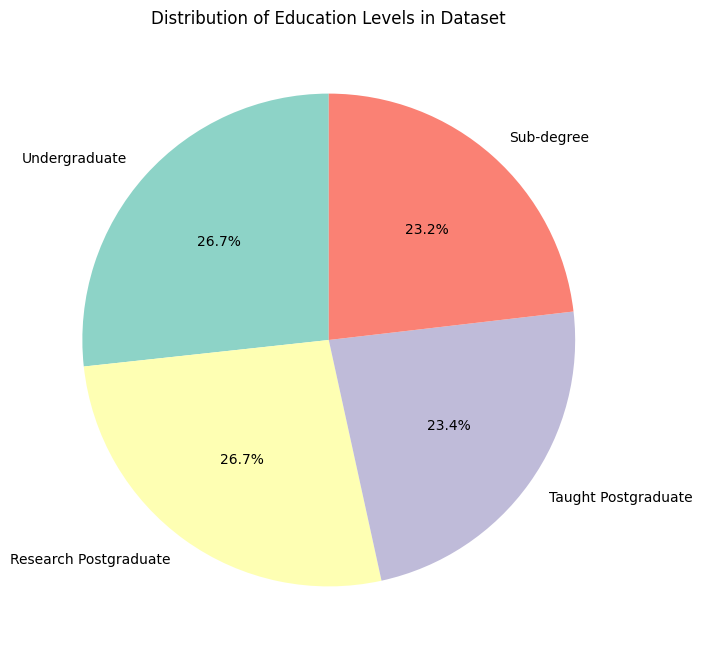

In [8]:
education_counts = df['Level of Study'].value_counts()
plt.figure(figsize=(8, 8), facecolor="white")
plt.pie(education_counts.values, labels=education_counts.index, autopct='%1.1f%%', startangle=90, textprops={'color': 'black'})
plt.title('Distribution of Education Levels in Dataset', color = "black")
plt.show()

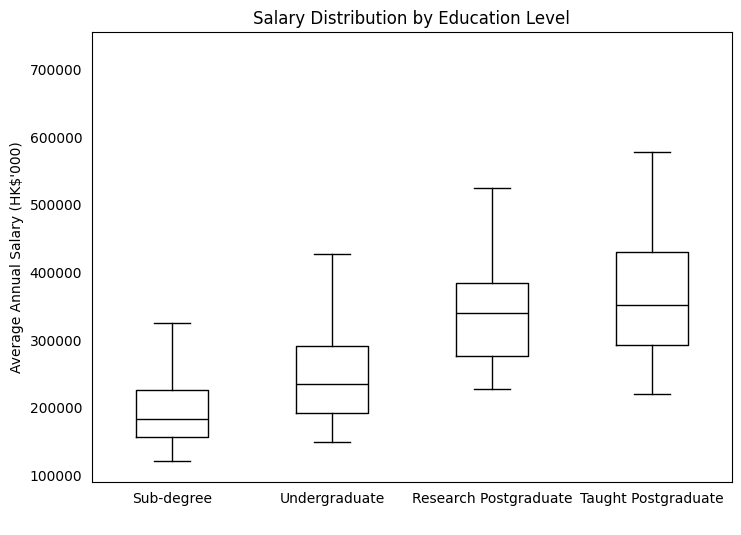

In [ ]:


degree_order = ['Sub-degree', 'Undergraduate', 'Research Postgraduate', 'Taught Postgraduate']
df['Level of Study'] = pd.Categorical(df['Level of Study'], categories=degree_order, ordered=True)

fig, ax = plt.subplots(figsize=(8,6))
df.boxplot(column="Average Annual Salary (HK$'000)", by='Level of Study', grid=False, ax = ax)
ax.set_title('Salary Distribution by Education Level')
plt.title('Salary Distribution by Education Level', color='black')
plt.ylabel("Average Annual Salary (HK$'000)", color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
plt.suptitle('')
boxes = ax.artists
for box in boxes:
    box.set_edgecolor('black')
    box.set_facecolor('white')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
for line in ax.lines:
    line.set_color('black')
plt.show()

In [ ]:
salary = df.groupby('Level of Study')["Average Annual Salary (HK$'000)"].agg(['mean', 'median', 'count'])
print(salary.round(0))

sub_avg = salary.loc["Sub-degree", 'mean']
under_avg = salary.loc["Undergraduate", 'mean']
res_avg = salary.loc["Research Postgraduate", 'mean']
taught_avg = salary.loc['Taught Postgraduate', 'mean']

print(f"\nSalary Increase:")
print(f"Sub-degree to Undergraduate: ${int(under_avg - sub_avg)} ({int(((under_avg/sub_avg)-1)*100)}%)")
print(f"Undergraduate to Research Posrtgraduate: ${int(res_avg - under_avg)} ({int(((res_avg/under_avg)-1)*100)}%)")
print(f"Research Posrtgraduate to Taught Posrtgraduate: ${int(taught_avg - res_avg)} ({int(((taught_avg/res_avg)-1)*100)}%)")

                           mean    median  count
Level of Study                                  
Sub-degree             193033.0  182000.0     91
Undergraduate          257952.0  234000.0    105
Research Postgraduate  339562.0  340000.0    105
Taught Postgraduate    365120.0  351000.0     92

Salary Increase:
Sub-degree to Undergraduate: $64919 (33%)
Undergraduate to Research Posrtgraduate: $81609 (31%)
Research Posrtgraduate to Taught Posrtgraduate: $25557 (7%)


C:\Users\Misha\AppData\Local\Temp\ipykernel_11232\2112987666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary = df.groupby('Level of Study')["Average Annual Salary (HK$'000)"].agg(['mean', 'median', 'count'])


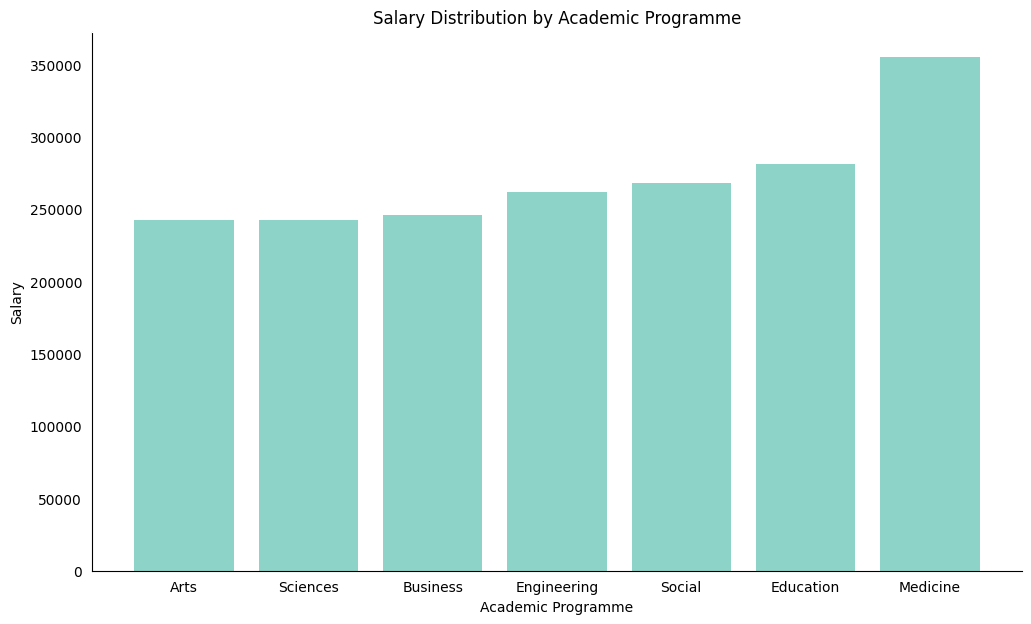

In [36]:
program_salary = df.groupby("Broad Academic Programme Category")["Average Annual Salary (HK$'000)"].median().sort_values(ascending=True)
plt.figure(figsize=(12,7))
plt.bar(program_salary.index, program_salary.values)
plt.title('Salary Distribution by Academic Programme', color='black')
plt.xlabel("Academic Programme", color = 'black')
plt.ylabel("Salary", color = 'black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')
ax = plt.gca()
ax.spines['bottom'].set_color('black')

ax.spines['left'].set_color('black')

plt.show()

In [12]:
#testing hypothesis
df_encoded = df.copy()
df_encoded['Education_encoded'] = df_encoded['Level of Study'].map({"Sub-degree": 0, "Undergraduate": 1, 'Research Postgraduate': 2, 'Taught Postgraduate': 3})
df_encoded['Academic Year'] = df_encoded['Academic Year'].map({
    "2009/10": 0, 
    "2010/11": 1, 
    "2011/12": 2, 
    "2012/13": 3,
    "2013/14": 4,
    "2014/15": 5,
    "2015/16": 6,
    "2016/17": 7,
    "2017/18": 8,
    "2018/19": 9,
    "2019/20": 10,
    "2020/21": 11,
    "2021/22": 12,
    "2022/23": 13,
    "2023/24": 14,})
df_encoded['Broad Academic Programme Category'] = df_encoded['Broad Academic Programme Category'].map({
    "Arts": 0, 
    "Sciences": 1, 
    'Business': 2, 
    'Engineering': 3,
    "Social": 4,
    "Education": 5,
    "Medicine": 6})


correlation = df_encoded['Education_encoded'].corr(df_encoded["Average Annual Salary (HK$'000)"], method='spearman')
print(f"Correlation between Education Level and Salary: {correlation}")

if correlation > 0.8:
    print("✅Correlation is very strong positive")
elif correlation > 0.6:
    print("✅Correlation is strong positive")
else:
    print("❌ Correlation is not that strong")

Correlation between Education Level and Salary: 0.673192787801327
✅Correlation is strong positive


In [13]:
#Now, we build simple regression model to predict the results
df_encoded.head()

,Academic Year,Level of Study,Broad Academic Programme Category,Average Annual Salary (HK$'000),Education_encoded
0,0,Sub-degree,6,292000,0
1,0,Sub-degree,1,125000,0
2,0,Sub-degree,3,125000,0
3,0,Sub-degree,2,139000,0
4,0,Sub-degree,4,163000,0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_encoded[['Education_encoded', 'Broad Academic Programme Category', 'Academic Year']]
y = df_encoded["Average Annual Salary (HK$'000)"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("R^2 Score:", r2_score(y_test, y_pred))

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print("\nSample predictions vs actual:")
print(comparison.head(10))

R^2 Score: 0.6402021232406969

Sample predictions vs actual:
   Actual      Predicted
0  270000  262109.763556
1  233000  294981.795786
2  241000  251103.180633
3  312000  183929.739095
4  448000  400340.729218
5  348000  419371.809421
6  245000  282949.884433
7  335000  350123.325970
8  336000  396333.315144
9  379000  266250.178250


In [15]:
def predict_salary(education, program, years_since_2010):
    features = [[education, program, years_since_2010]]
    return int(model.predict(features)[0])
import warnings
warnings.filterwarnings('ignore')
print("Prediction of salary of a person in 2023, taugth postgraduate degree in Medicine: ")
print("HK$",predict_salary(3,6,14), sep ='')

Prediction of salary of a person in 2023, taugth postgraduate degree in Medicine: 
HK$500006
